# INTRODUCCION

# Preparación de los datos

Importamos nuestras librerías:

In [59]:
import pandas as pd
pd.set_option("display.float_format", "{:,.2f}".format)
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings("ignore")

Cargamos los Datasets utilizados para el análisis

In [60]:
costs = pd.read_csv("datasets/costs_us.csv")
orders = pd.read_csv("datasets/orders_log_us.csv")
visits = pd.read_csv("datasets/visits_log_us.csv")

# Exploración de los datos

## costs

In [61]:
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB


Identificamos las primeras y las ultimas 5 filas

In [62]:
print(costs.head())
print(costs.tail())

   source_id          dt  costs
0          1  2017-06-01  75.20
1          1  2017-06-02  62.25
2          1  2017-06-03  36.53
3          1  2017-06-04  55.00
4          1  2017-06-05  57.08
      source_id          dt  costs
2537         10  2018-05-27   9.92
2538         10  2018-05-28  21.26
2539         10  2018-05-29  11.32
2540         10  2018-05-30  33.15
2541         10  2018-05-31  17.60


Buscamos duplicados

In [63]:
costs.duplicated().sum()

np.int64(0)

No existen valores nulos o duplicados, pero hace falta convertir el tipo de datos de la columna `dt` a **datetime**

También es necesario cambiar el formato del nombre de las columnas a snake_case

## orders

In [64]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB


Mostramos las primeras y ultimas 5 filas

In [65]:
print(orders.head())
print(orders.tail())

                Buy Ts  Revenue                   Uid
0  2017-06-01 00:10:00    17.00  10329302124590727494
1  2017-06-01 00:25:00     0.55  11627257723692907447
2  2017-06-01 00:27:00     0.37  17903680561304213844
3  2017-06-01 00:29:00     0.55  16109239769442553005
4  2017-06-01 07:58:00     0.37  14200605875248379450
                    Buy Ts  Revenue                   Uid
50410  2018-05-31 23:50:00     4.64  12296626599487328624
50411  2018-05-31 23:50:00     5.80  11369640365507475976
50412  2018-05-31 23:54:00     0.30   1786462140797698849
50413  2018-05-31 23:56:00     3.67   3993697860786194247
50414  2018-06-01 00:02:00     3.42     83872787173869366


Buscamos valores duplicados

In [66]:
orders.duplicated().sum()

np.int64(0)

No existen valores nulos ni duplicados.

Hace falta cambiar el tipo de la columna `Buy Ts` a datetime

El formato del nombre de las columnas se debe cambiar a snake_case

# visits

In [67]:
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB


Mostramos las primeras y ultimas 5 filas

In [68]:
print(visits.head())
print(visits.tail())


    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   

                    Uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4   9969694820036681168  
         Device               End Ts  Source Id             Start Ts  \
359395  desktop  2017-07-29 19:07:19          2  2017-07-29 19:07:00   
359396    touch  2018-01-25 17:38:19          1  2018-01-25 17:38:00   
359397  desktop  2018-03-03 10:12:19          4  2018-03-03 10:12:00   
359398  desktop  2017-11-02 10:12:19          5  2017-11-02 10:12:00   
359399    touch  2017-09-10 13:13:19          2  2017-09-10 13:13:00   

        

Buscamos valores duplicados

In [69]:
visits.duplicated().sum()

np.int64(0)

Al igual que los otros datasets, no se encontraron valores nulos ni duplicados y se debe modificar el formato de los nombres 

El tipo de las columnas `Start Ts` y `End Ts` debe ser **datetime**

# Procesamiento de los datos

## costs

Cambiamos el formato de los nombres de las columnas:

In [70]:
new_col_names = []

for old_name in costs.columns:
    name_stripped = old_name.strip()
    name_lowered = name_stripped.lower()
    name_no_spaces = name_lowered.replace(" ", "_")
    new_col_names.append(name_no_spaces)

costs.columns = new_col_names

costs.columns

Index(['source_id', 'dt', 'costs'], dtype='object')

Cambiamos el tipo de la columna `dt`

In [71]:
costs["dt"] = pd.to_datetime(costs["dt"])

print(costs["dt"].dtype)

datetime64[ns]


## orders

Cambiamos el formato de los nombres de las columnas:

In [72]:
new_col_names = []

for old_name in orders.columns:
    name_stripped = old_name.strip()
    name_lowered = name_stripped.lower()
    name_no_spaces = name_lowered.replace(" ", "_")
    new_col_names.append(name_no_spaces)

orders.columns = new_col_names

orders.columns

Index(['buy_ts', 'revenue', 'uid'], dtype='object')

Cambiamos el tipo de la columna `buy_ts`

In [73]:
orders["buy_ts"] = pd.to_datetime(orders["buy_ts"])

print(orders["buy_ts"].dtypes)

datetime64[ns]


## visits

Cambiamos el formato de los nombres de las columnas

In [74]:
new_col_names = []

for old_name in visits.columns:
    name_stripped = old_name.strip()
    name_lowered = name_stripped.lower()
    name_no_spaces = name_lowered.replace(" ", "_")
    new_col_names.append(name_no_spaces)

visits.columns = new_col_names

visits.columns

Index(['device', 'end_ts', 'source_id', 'start_ts', 'uid'], dtype='object')

Cambiamos el tipo de las columnas `start_ts` y `end_ts`

In [75]:
visits["start_ts"] = pd.to_datetime(visits["start_ts"])
visits["end_ts"] = pd.to_datetime(visits["end_ts"])

print(visits["start_ts"].dtypes, visits["end_ts"].dtypes)

datetime64[ns] datetime64[ns]


# Análisis de datos

## ¿Cuantas personas utilizan Showz diaria, semanal y mensualmente?

Comenzamos creando las columnas `year`, `iso_year`, `month`, `iso_week` y `date` en nuestro dataset **visits**

In [76]:
visits["year"] = visits["start_ts"].dt.year # Año en formato estándar para obtener el MAU
visits["iso_year"] = visits["start_ts"].dt.isocalendar().year # Año en formato iso para obtener el WAU 
visits["month"] = visits["start_ts"].dt.month
visits["iso_week"] = visits["start_ts"].dt.isocalendar().week
visits["date"] = visits["start_ts"].dt.date

Calculamos **DAU**, **WAU** y **MAU** 

In [77]:
dau_total = visits.groupby("date").agg({"uid": "nunique"}).mean()

wau_total = visits.groupby(["iso_year", "iso_week"]).agg({"uid": "nunique"}).mean()

mau_total = visits.groupby(["year", "month"]).agg({"uid": "nunique"}).mean()

print("El DAU es:", int(dau_total))
print("El WAU es:", int(wau_total))
print("El MAU es:", int(mau_total))

El DAU es: 907
El WAU es: 5716
El MAU es: 23228


Calculamos el sticky factor mensual:

In [86]:
sticky_factor = dau_total / mau_total

print(sticky_factor)

uid   0.04
dtype: float64


Creamos una gráfica para observar la evolución del MAU a lo largo del tiempo

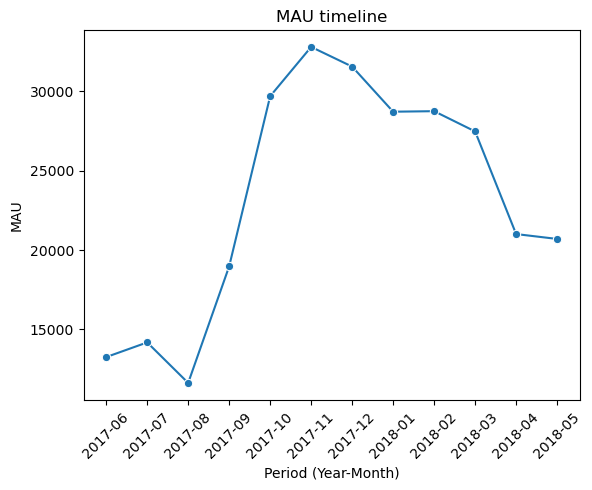

In [ ]:
# Creamos la columna "period" 
visits["period"] = visits["start_ts"].dt.strftime("%Y-%m")

mau_timeline = visits.groupby("period").agg({"uid": "nunique"})

mau_lineplot = sns.lineplot(x="period", y="uid", marker="o", data=mau_timeline)

plt.title("MAU timeline")
plt.xlabel("Period (Year-Month)")
plt.ylabel("MAU")
plt.xticks(rotation=45);

>Nota: el dataset no cubre el período completo anunciado en las instrucciones del proyecto. Los primeros y últimos meses pueden mostrar valores atípicos por datos parciales, por lo que las tendencias de inicio y cierre deben interpretarse con cautela.

### Conclusión

Se observan tres momentos clave en el período analizado. El punto más bajo de usuarios activos se registró en agosto de 2017, seguido de un crecimiento acelerado que alcanzó su punto máximo en noviembre del mismo año. A partir de diciembre de 2017 la actividad comenzó a disminuir de forma paulatina, lo cual es un comportamiento esperado después de un pico; sin embargo, los niveles de actividad no volvieron a los mínimos registrados al inicio del período, lo que sugiere un crecimiento neto positivo.

Este comportamiento podría explicarse por una campaña de marketing exitosa y una mayor inversión publicitaria en ese período. Si esta hipótesis se confirma al revisar los costos de adquisición, el equipo de marketing debería identificar qué canales fueron más activos entre septiembre y noviembre de 2017 para evaluar si la estrategia es replicable.